# EDA — Asteroid Hazard Prediction

This notebook explores the NASA Near-Earth Objects dataset (1910–2024) before building the ML pipeline.
Goal: understand the data, find problems, decide what to keep and what to drop.

Dataset: 338,199 asteroid close-approach records from NASA's NeoWs database.
Target: is_hazardous — True means the asteroid is classified as potentially dangerous to Earth.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## 1. Load the Data

In [33]:
df = pd.read_csv('../data/raw.csv')
print(df.shape)
df.head()

(338199, 9)


,neo_id,name,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,orbiting_body,relative_velocity,miss_distance,is_hazardous
0,2162117,162117 (1998 SD15),19.14,0.394962,0.883161,Earth,71745.401048,5.814362e+07,False
1,2349507,349507 (2008 QY),18.50,0.530341,1.185878,Earth,109949.757148,5.580105e+07,True
2,2455415,455415 (2003 GA),21.45,0.136319,0.304818,Earth,24865.506798,6.720689e+07,False
3,3132126,(2002 PB),20.63,0.198863,0.444672,Earth,78890.076805,3.039644e+07,False
4,3557844,(2011 DW),22.70,0.076658,0.171412,Earth,56036.519484,6.311863e+07,False


## 2. Basic Info

338,199 rows, 9 columns.

Columns:
- neo_id, name: asteroid identifiers — not useful for prediction
- absolute_magnitude: brightness of the asteroid. Dimmer = smaller. Scale is inverted — higher number means dimmer/smaller.
- estimated_diameter_min / max: size range in kilometers
- orbiting_body: which planet it orbits near — turns out it's always Earth, so useless
- relative_velocity: how fast it's moving relative to Earth (km/h)
- miss_distance: how close it came to Earth (km)
- is_hazardous: our target — True or False

Data types look correct. Three columns have 28 missing values — we'll handle those later.

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338199 entries, 0 to 338198
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   neo_id                  338199 non-null  int64  
 1   name                    338199 non-null  object 
 2   absolute_magnitude      338171 non-null  float64
 3   estimated_diameter_min  338171 non-null  float64
 4   estimated_diameter_max  338171 non-null  float64
 5   orbiting_body           338199 non-null  object 
 6   relative_velocity       338199 non-null  float64
 7   miss_distance           338199 non-null  float64
 8   is_hazardous            338199 non-null  bool   
dtypes: bool(1), float64(5), int64(1), object(2)
memory usage: 21.0+ MB


In [35]:
df.describe()

,neo_id,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,relative_velocity,miss_distance
count,3.381990e+05,338171.000000,338171.000000,338171.000000,338199.000000,3.381990e+05
mean,1.759939e+07,22.932525,0.157812,0.352878,51060.662908,4.153535e+07
std,2.287225e+07,2.911216,0.313885,0.701869,26399.238435,2.077399e+07
min,2.000433e+06,9.250000,0.000511,0.001143,203.346433,6.745533e+03
25%,3.373980e+06,20.740000,0.025384,0.056760,30712.031471,2.494540e+07
50%,3.742127e+06,22.800000,0.073207,0.163697,47560.465474,4.332674e+07
75%,5.405374e+07,25.100000,0.189041,0.422708,66673.820614,5.933961e+07
max,5.446281e+07,33.580000,37.545248,83.953727,291781.106613,7.479865e+07


## 3. Target Distribution — Class Imbalance Check

This is the most important check before anything else.
We need to know: how many asteroids are hazardous vs not?
If the split is very unequal, a dumb model that always predicts False would still get high accuracy — which is useless.

is_hazardous
False    295037
True      43162
Name: count, dtype: int64

Class ratio:
is_hazardous
False    87.237691
True     12.762309
Name: count, dtype: float64


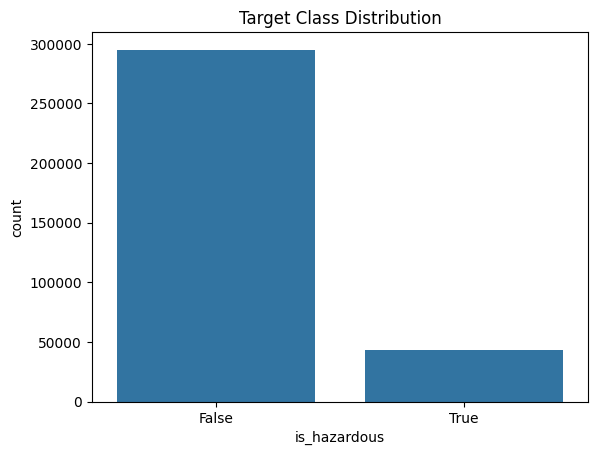

In [36]:
target_counts = df['is_hazardous'].value_counts()
print(target_counts)
print("\nClass ratio:")
print(target_counts / len(df) * 100)

sns.countplot(x='is_hazardous', data=df)
plt.title('Target Class Distribution')
plt.show()

## Finding: Imbalanced Dataset

False (not hazardous): 295,037 — 87.2%
True (hazardous):       43,162 — 12.8%

Roughly 7:1 ratio. This is a moderately imbalanced dataset.
A model that always predicts False would get 87% accuracy — but zero usefulness.
This means accuracy is a bad metric for this problem.
We will use F1-score and Recall on the True class as our primary metrics.
We will apply SMOTE during training to synthetically balance the classes.

## 4. Missing Values

In [37]:
missing = df.isnull().sum()
print(missing[missing > 0])

absolute_magnitude        28
estimated_diameter_min    28
estimated_diameter_max    28
dtype: int64


## Finding: Missing Values

absolute_magnitude, estimated_diameter_min, estimated_diameter_max — each has 28 missing values.
28 out of 338,199 rows = 0.008% of the data. Essentially nothing.
We will drop these rows during data transformation. Too few to bother imputing.

## 5. Drop Useless Columns

orbiting_body: check if it's always "Earth" — if yes, it carries zero information, every row is the same value.
neo_id, name: just identifiers, not measurements. A model should never learn from an asteroid's name or ID.

In [38]:
print(df['orbiting_body'].value_counts())
# no sentry_object column in this dataset, skip that line

cols_to_drop = ['neo_id', 'name', 'orbiting_body']
df_clean = df.drop(columns=cols_to_drop)
print(df_clean.shape)
df_clean.head()

orbiting_body
Earth    338199
Name: count, dtype: int64
(338199, 6)


,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,relative_velocity,miss_distance,is_hazardous
0,19.14,0.394962,0.883161,71745.401048,5.814362e+07,False
1,18.50,0.530341,1.185878,109949.757148,5.580105e+07,True
2,21.45,0.136319,0.304818,24865.506798,6.720689e+07,False
3,20.63,0.198863,0.444672,78890.076805,3.039644e+07,False
4,22.70,0.076658,0.171412,56036.519484,6.311863e+07,False


## Finding: Columns Dropped

orbiting_body is "Earth" for all 338,199 rows — confirmed useless, dropped.
neo_id and name are identifiers with no predictive value, dropped.

Remaining shape: (338,199, 6) — 5 features + 1 target.

## 6. Feature Distributions

Looking at the shape of each feature — are values spread out, or bunched up on one side?
Heavily skewed features can hurt some models. We'll note which ones are skewed.

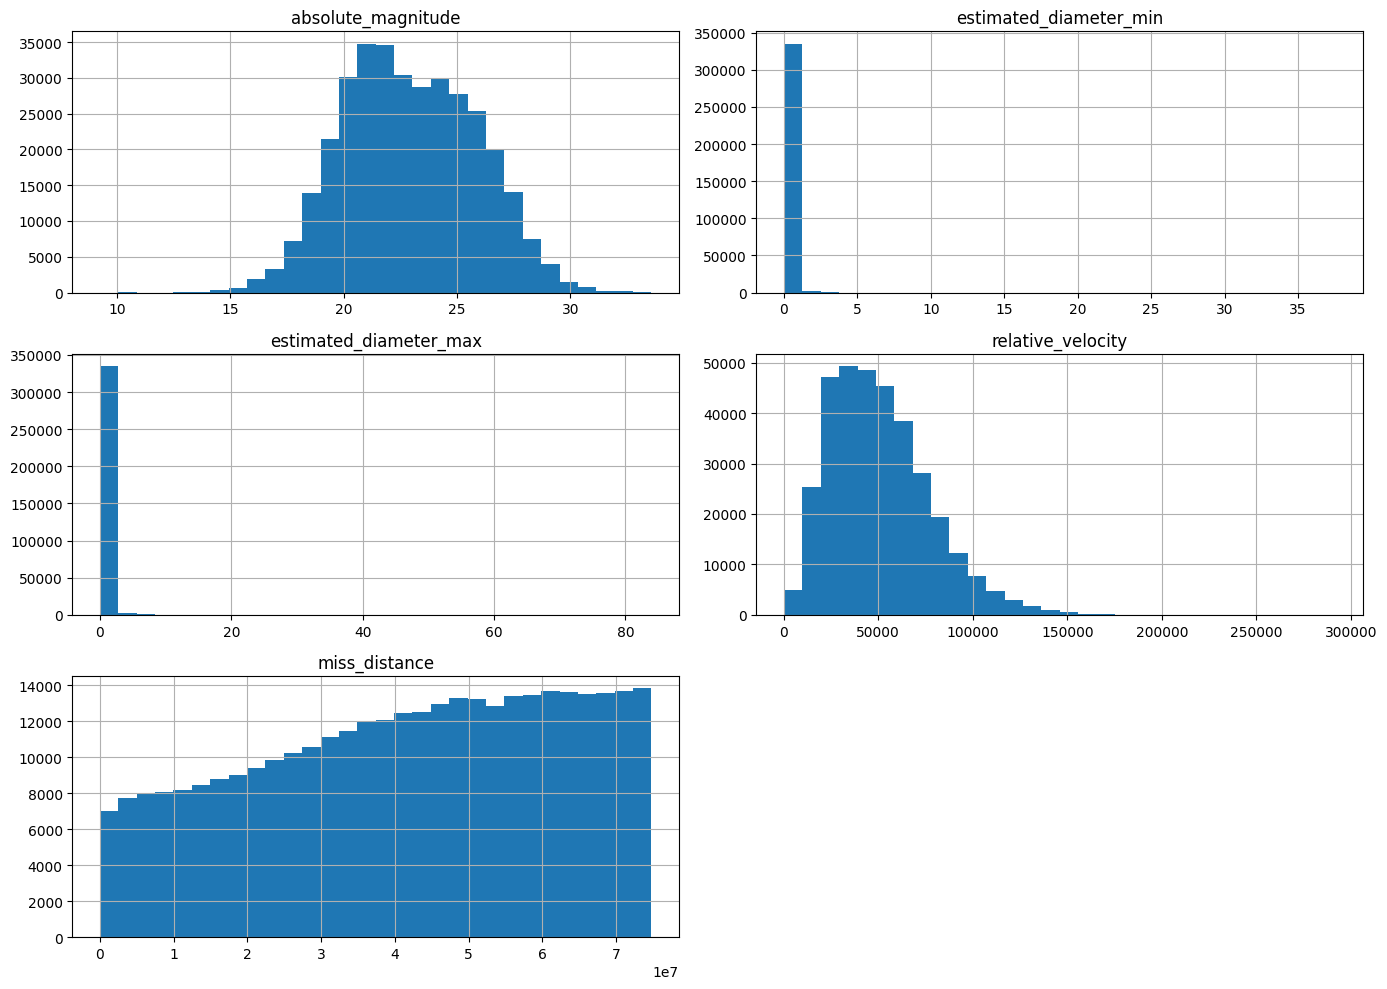

In [39]:
df_clean.hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

## Finding: Feature Distributions

- absolute_magnitude: roughly bell-shaped, centred around 22. Looks normal. Good.
- estimated_diameter_min / max: heavily right-skewed. Most asteroids are small,
  but a few are enormous. The tail stretches far right. These will need scaling.
- relative_velocity: right-skewed. Most asteroids move at moderate speed,
  a few are extremely fast outliers.
- miss_distance: roughly uniform — asteroids are recorded at all distances fairly evenly.

Conclusion: diameter and velocity features are skewed with outliers.
We will use RobustScaler in the pipeline — it handles outliers better than StandardScaler
because it scales using the median and IQR instead of mean and standard deviation.

## 7. Correlation Heatmap

Correlation measures how strongly two variables move together.
Value of 1.0 = perfect positive relationship.
Value of -1.0 = perfect negative relationship.
Value near 0 = no linear relationship.

We are looking for two things:
1. Which features correlate with is_hazardous (our target)?
2. Are any two features so correlated with each other that one is redundant?

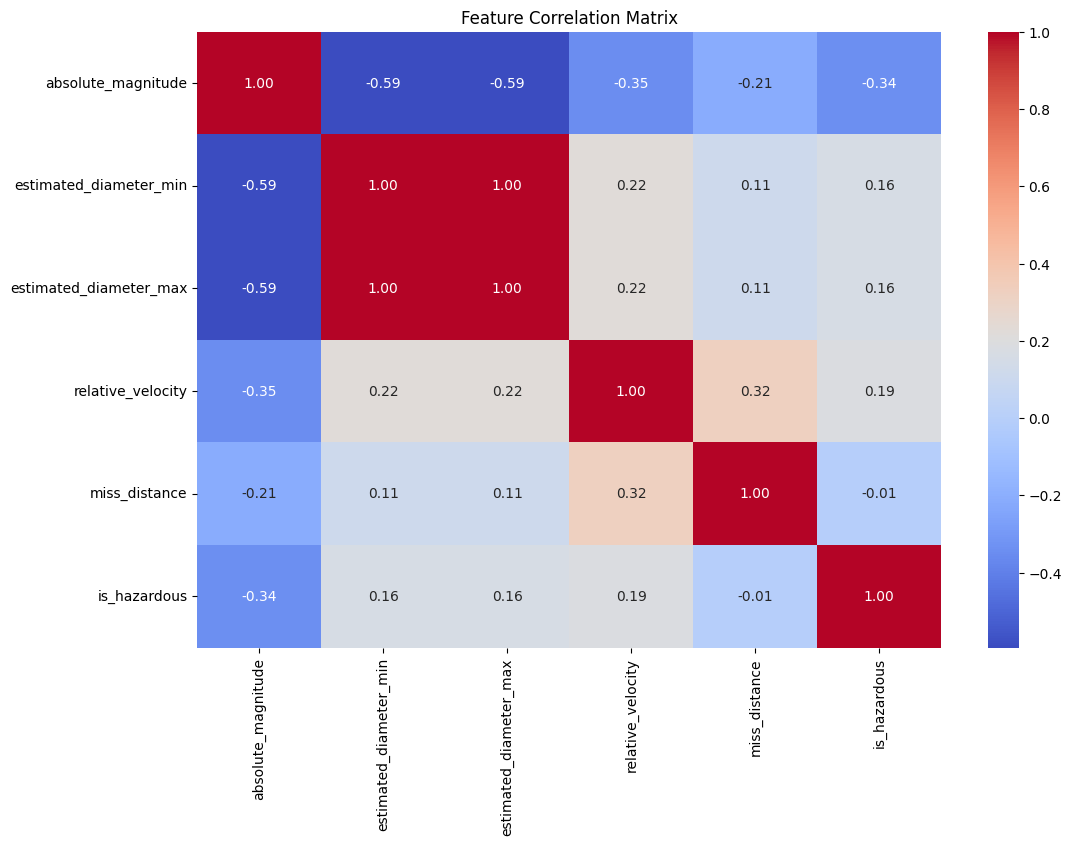

In [40]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

## Finding: Correlation Heatmap

Features vs target (is_hazardous):
- absolute_magnitude: -0.34 — moderate negative correlation.
  Lower magnitude = brighter = larger asteroid = more likely hazardous. Makes physical sense.
- estimated_diameter_min / max: 0.16 — weak positive. Larger asteroids slightly more hazardous.
- relative_velocity: 0.19 — weak positive. Faster asteroids slightly more hazardous.
- miss_distance: -0.01 — almost zero. Distance alone does not determine hazard status.

Feature-to-feature (multicollinearity check):
- estimated_diameter_min vs estimated_diameter_max: 1.00 — perfect correlation.
  They are the same information expressed twice. We should drop one.
  We will drop estimated_diameter_min and keep estimated_diameter_max.
- absolute_magnitude vs diameter: -0.59 — expected, brightness and size are related.

No other dangerous multicollinearity found.

## 8. Feature vs Target — Box Plots

Box plots show the distribution of each feature split by hazardous vs not hazardous.
If the boxes for True and False are clearly separated, that feature is useful for prediction.
If they completely overlap, the feature adds little signal.

How to read a box plot:
- The middle line = median (middle value)
- The box = where the middle 50% of data sits
- The whiskers = the full range (excluding extreme outliers)
- The dots = outliers

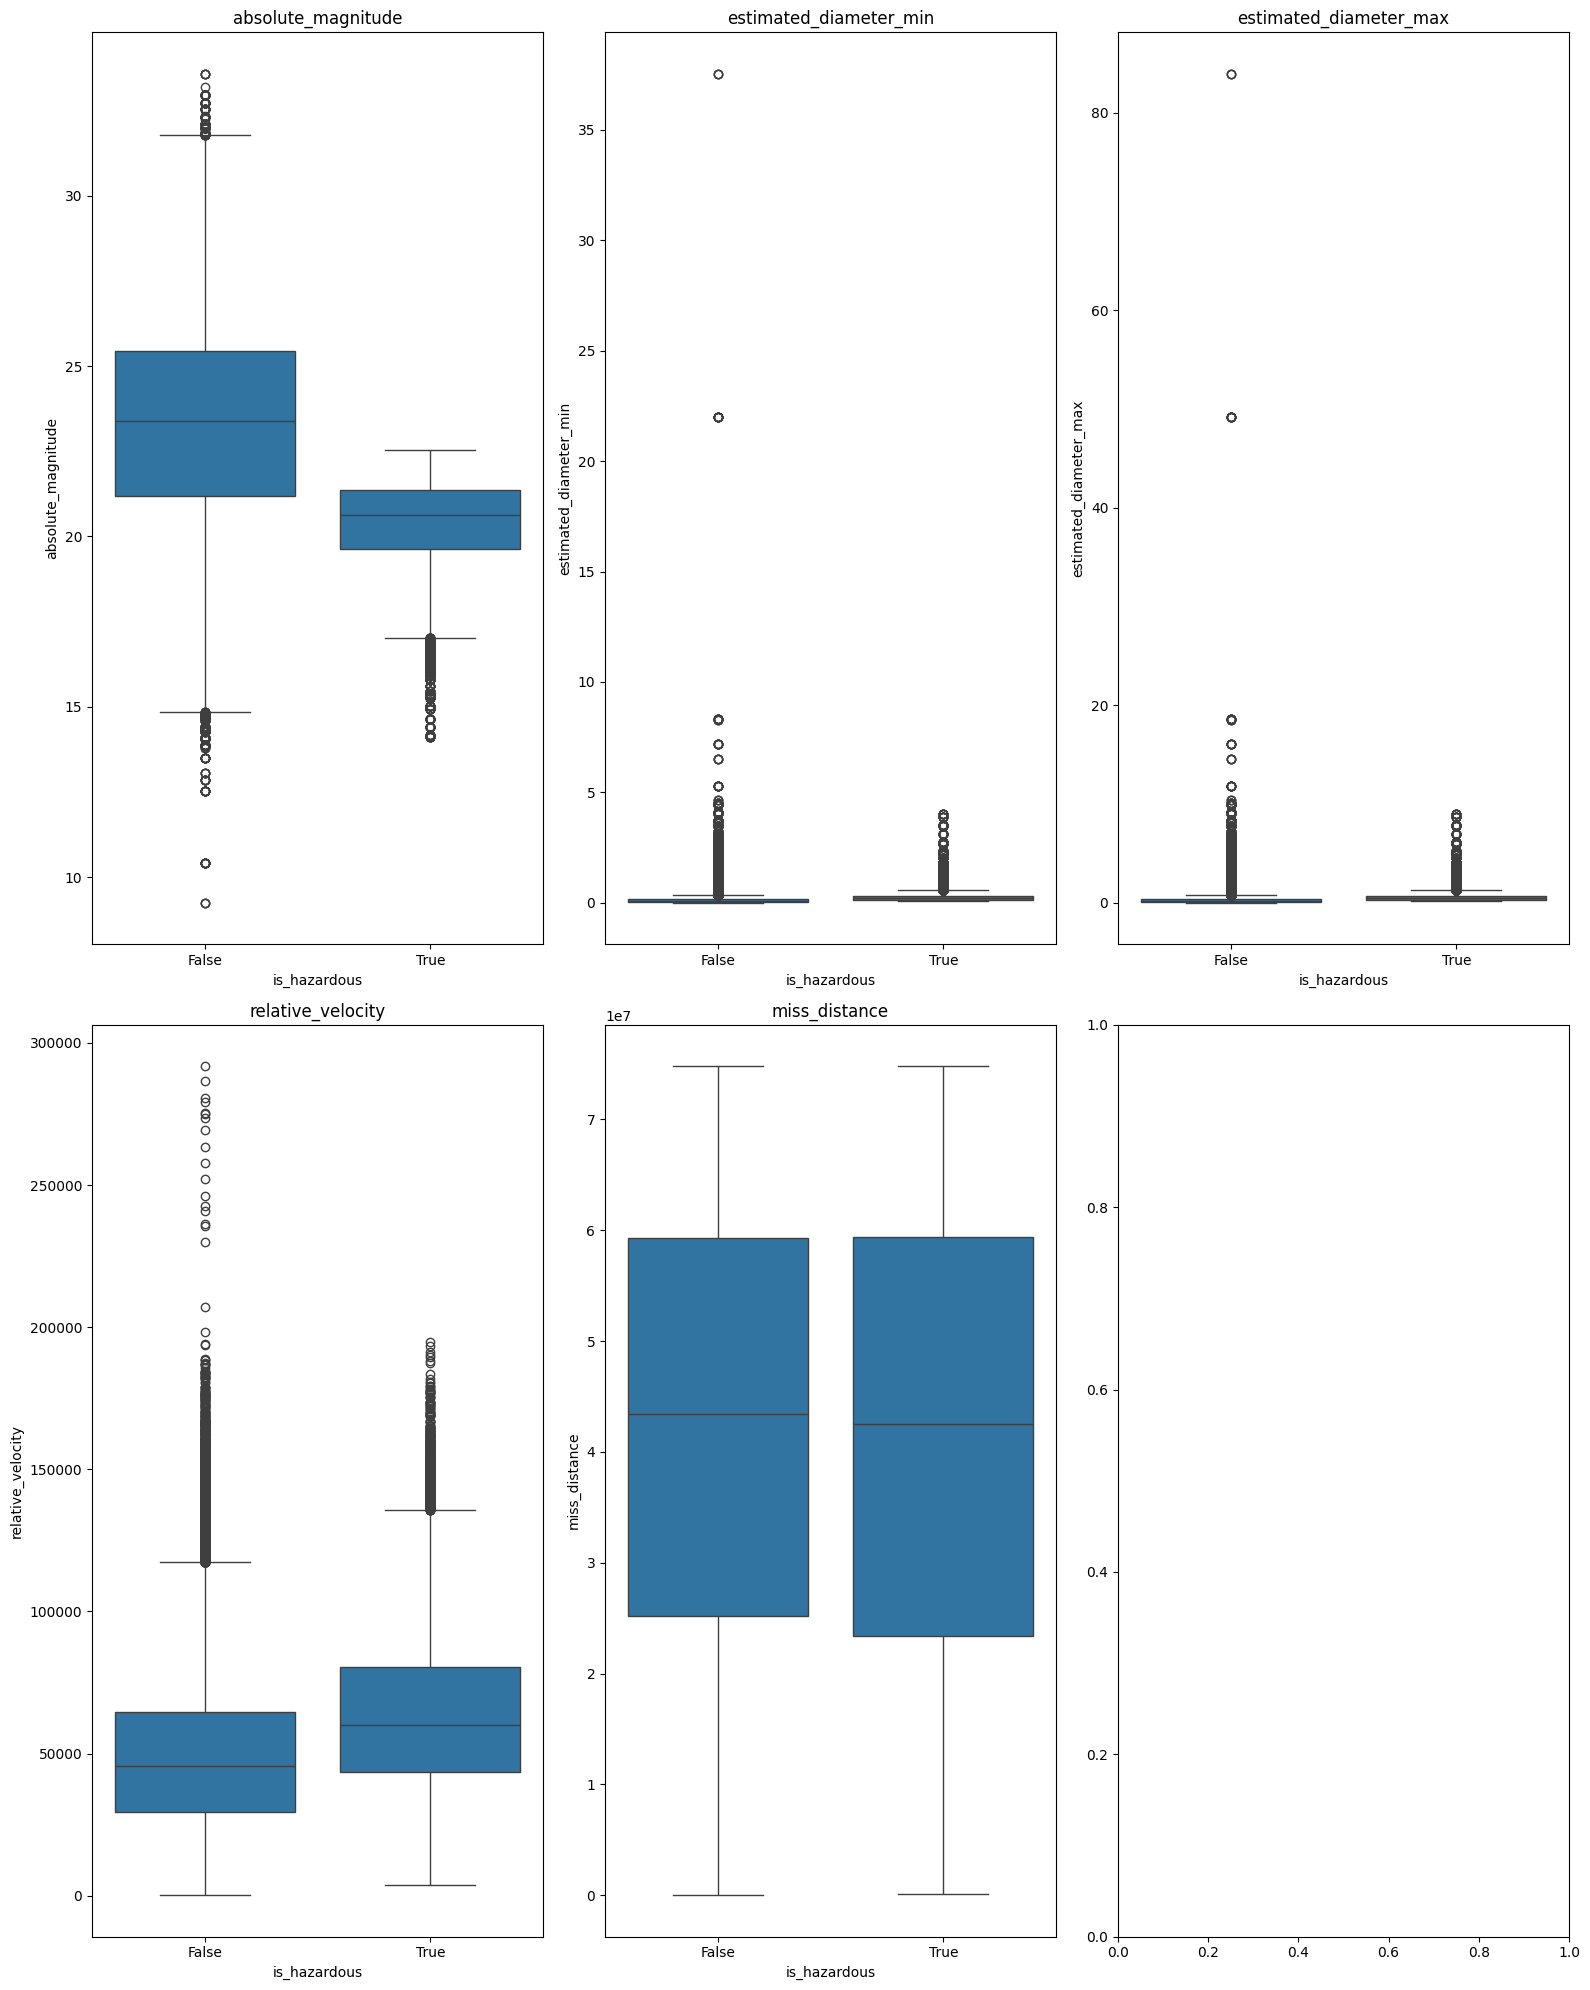

In [41]:
features = df_clean.drop('is_hazardous', axis=1).columns

fig, axes = plt.subplots(nrows=len(features)//3 + 1, ncols=3, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x='is_hazardous', y=col, data=df_clean, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## Finding: Feature vs Target

- absolute_magnitude: hazardous asteroids (True) have a clearly lower median magnitude
  than non-hazardous ones. The boxes are separated. Strong signal. Most useful feature.
- estimated_diameter_min / max: hazardous asteroids tend to be slightly larger,
  but the overlap is significant. Moderate signal.
- relative_velocity: hazardous asteroids move slightly faster on average.
  Some separation visible but lots of overlap. Weak-to-moderate signal.
- miss_distance: boxes are nearly identical for True and False.
  Confirms the correlation finding — distance is not a reliable predictor on its own.

Summary: absolute_magnitude is the strongest individual predictor.
The model will need to combine all features together to do well.

## 9. EDA Summary — Decisions for the Pipeline

| Decision | Reason |
|---|---|
| Drop neo_id, name, orbiting_body | Identifiers or constants, no predictive value |
| Drop estimated_diameter_min | Perfect duplicate of estimated_diameter_max (correlation = 1.0) |
| Drop 28 rows with missing values | 0.008% of data, not worth imputing |
| Use RobustScaler | Skewed features + outliers in diameter and velocity |
| Apply SMOTE on train set only | 7:1 class imbalance |
| Evaluate using F1 + Recall on True class | Accuracy is misleading on imbalanced data |
| Primary feature: absolute_magnitude | Strongest correlation with target |